# RoboNose — phân tích dữ liệu thử nghiệm đầu tiên

Notebook này trả lời hai câu hỏi khác nhau:

1. **Thiết bị có tạo ra fingerprint khác nhau giữa các loại mẫu không?**  
   Đánh giá sơ bộ bằng độ lớn đáp ứng, độ lặp lại giữa `trial01` và `trial02`, PCA và phép ghép nearest-neighbour chéo trial.
2. **Dữ liệu hiện tại có chứng minh được nhận diện người qua mùi không?**  
   Không: dữ liệu hiện chỉ có một người (không có `person_code`) và 2 lần lặp/mẫu. Notebook chỉ đánh giá tính khả thi kỹ thuật ban đầu, không tuyên bố khả năng nhận diện người.

Đơn vị độc lập là **một run**, không phải từng dòng 1 Hz. Chia train/test theo dòng sẽ rò rỉ chuỗi thời gian và tạo accuracy ảo.

## 0. Thiết kế phần cứng và giả thuyết phân tích

- BME688: gas resistance cùng nhiệt độ/độ ẩm/áp suất. Dữ liệu này dùng một heater cố định 320 °C, chưa phải heater profile nhiều mức.
- MQ135 và MQ3: đọc điện áp ADS1115; hệ số voltage divider chưa được xác nhận, vì vậy ưu tiên thay đổi tương đối so với baseline trong cùng run.
- Pha chuẩn: baseline 60 s → exposure 120 s → recovery 60 s; các pha `WAIT_*` và `MONITOR` không dùng để học fingerprint.
- Hai trial đổi thứ tự đo, nhưng recovery chưa luôn về nền; cần coi carry-over và drift theo thời gian là nhiễu quan trọng.

In [1]:
from pathlib import Path
import json, re, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.spatial.distance import cdist, pdist
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

# Chạy được khi mở notebook từ root hoặc từ thư mục con.
cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents] if (p / "data" / "first_trial").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Không tìm thấy data/first_trial. Hãy chạy notebook trong dự án PBL6.")
DATA_DIR = PROJECT_ROOT / "data" / "first_trial"
print("Project:", PROJECT_ROOT)
print("Data:", DATA_DIR)

Project: D:\PBL6
Data: D:\PBL6\data\first_trial


## 1. Kiểm kê toàn bộ thư mục dữ liệu

In [2]:
LABEL_VI = {
    "khongkhi": "Không khí",
    "ao": "Áo",
    "nach": "Nách",
    "nuochoa": "Nước hoa",
    "mamtom": "Mắm tôm",
}
PRIMARY_RE = re.compile(r"^trial(?P<trial>0[12])_(?P<label>khongkhi|ao|nach|nuochoa|mamtom)_")

records = []
for run_dir in sorted(p for p in DATA_DIR.iterdir() if p.is_dir()):
    files = {p.name: p for p in run_dir.iterdir() if p.is_file()}
    metadata = json.loads(files["metadata.json"].read_text(encoding="utf-8")) if "metadata.json" in files else {}
    summary = json.loads(files["summary.json"].read_text(encoding="utf-8")) if "summary.json" in files else {}
    match = PRIMARY_RE.match(run_dir.name)
    phase_intervals = metadata.get("phase_intervals", [])
    records.append({
        "folder": run_dir.name,
        "primary": bool(match),
        "trial": int(match.group("trial")) if match else np.nan,
        "label": match.group("label") if match else None,
        "label_vi": LABEL_VI.get(match.group("label")) if match else None,
        "started_at": metadata.get("started_at"),
        "status": metadata.get("status"),
        "rows_metadata": metadata.get("rows"),
        "rows_summary": summary.get("rows"),
        "n_files": len(files),
        "has_raw": "raw.csv" in files,
        "has_events": "events.csv" in files,
        "baseline_s": next((x.get("actual_s") for x in phase_intervals if x.get("phase") == "BASELINE"), np.nan),
        "exposure_s": next((x.get("actual_s") for x in phase_intervals if x.get("phase") == "EXPOSURE"), np.nan),
        "recovery_s": next((x.get("actual_s") for x in phase_intervals if x.get("phase") == "RECOVERY"), np.nan),
        "baseline_stable": metadata.get("baseline_quality", {}).get("stable"),
        "baseline_unstable": metadata.get("baseline_unstable"),
        "warnings": " | ".join(summary.get("warnings", [])),
        "path": run_dir,
    })

inventory = pd.DataFrame(records).sort_values(["primary", "started_at"], ascending=[False, True]).reset_index(drop=True)
print(f"Tổng số run: {len(inventory)}; run chính: {int(inventory.primary.sum())}; run test/phụ: {int((~inventory.primary).sum())}")
display(inventory.drop(columns="path"))

file_inventory = pd.DataFrame([
    {"relative_path": str(p.relative_to(PROJECT_ROOT)), "suffix": p.suffix.lower(), "bytes": p.stat().st_size}
    for p in sorted((PROJECT_ROOT / "data").rglob("*")) if p.is_file()
])
display(file_inventory.groupby("suffix").agg(files=("relative_path", "size"), total_bytes=("bytes", "sum")))

Tổng số run: 18; run chính: 10; run test/phụ: 8


,folder,primary,trial,label,label_vi,started_at,status,rows_metadata,rows_summary,n_files,has_raw,has_events,baseline_s,exposure_s,recovery_s,baseline_stable,baseline_unstable,warnings
0,trial01_khongkhi_20261003_154917_4793290d6ecf4...,True,1.0,khongkhi,Không khí,2026-10-03T15:49:17.212791+07:00,COMPLETE,1076,1076,6,True,True,60.0,120.0,60.0,True,False,Chất lượng baseline: Nhiệt độ BME vượt 35.0 °C...
1,trial01_ao_20261003_160739_ac7c1fb6273f4dd882b...,True,1.0,ao,Áo,2026-10-03T16:07:39.606117+07:00,COMPLETE,306,306,6,True,True,60.0,120.0,60.0,True,False,Chất lượng baseline: Nhiệt độ BME vượt 35.0 °C...
2,trial01_nach_20261003_161305_0bf084ef31f7482eb...,True,1.0,nach,Nách,2026-10-03T16:13:05.645002+07:00,COMPLETE,314,314,6,True,True,60.0,120.0,60.0,True,False,Chất lượng baseline: Nhiệt độ BME vượt 35.0 °C...
3,trial01_nuochoa_20261003_161838_0f9ab45ab2fe4a...,True,1.0,nuochoa,Nước hoa,2026-10-03T16:18:38.961467+07:00,COMPLETE,369,369,6,True,True,60.0,120.0,60.0,False,True,Chất lượng baseline: gas_resistance_ohm: đang ...
4,trial01_mamtom_20261003_162504_ebb6bf010ea247b...,True,1.0,mamtom,Mắm tôm,2026-10-03T16:25:04.272268+07:00,COMPLETE,322,322,6,True,True,60.0,120.0,60.0,True,False,Chất lượng baseline: Nhiệt độ BME vượt 35.0 °C...
5,trial02_khongkhi_20261003_163741_ab14be9977d64...,True,2.0,khongkhi,Không khí,2026-10-03T16:37:41.972324+07:00,COMPLETE,1191,1191,6,True,True,60.0,120.0,60.0,True,False,Chất lượng baseline: Nhiệt độ BME vượt 35.0 °C...
6,trial02_mamtom_20261003_165755_18ebb433656a4f7...,True,2.0,mamtom,Mắm tôm,2026-10-03T16:57:55.363291+07:00,COMPLETE,303,303,6,True,True,60.0,120.0,60.0,True,False,Chất lượng baseline: Nhiệt độ BME vượt 35.0 °C...
7,trial02_ao_20261003_170318_5f6a39ae4ae94318927...,True,2.0,ao,Áo,2026-10-03T17:03:18.387791+07:00,COMPLETE,425,425,6,True,True,60.0,120.0,60.0,True,False,Chất lượng baseline: Nhiệt độ BME vượt 35.0 °C...
8,trial02_nuochoa_20261003_171154_7783349cdcd74b...,True,2.0,nuochoa,Nước hoa,2026-10-03T17:11:54.071803+07:00,COMPLETE,332,332,6,True,True,60.0,120.0,60.0,False,True,Chất lượng baseline: gas_resistance_ohm: đang ...
9,trial02_nach_20261003_171747_85b4985b8d1f4a73a...,True,2.0,nach,Nách,2026-10-03T17:17:47.910435+07:00,COMPLETE,444,444,6,True,True,60.0,120.0,60.0,True,False,Chất lượng baseline: Nhiệt độ BME vượt 35.0 °C...


,files,total_bytes
suffix,,
.csv,36,8783090
.json,36,360677
.png,36,12366458
.txt,2,5371


**Quy tắc chống rò rỉ:** các folder không có tiền tố `trial01_`/`trial02_` là các lần test/monitor để tối ưu, một số chạy cùng thời điểm và chứa tín hiệu trùng với run chính. Chúng được kiểm kê ở trên nhưng không dùng như mẫu độc lập.

## 2. Đọc và kiểm tra chất lượng 10 run chính

In [3]:
SIGNALS = ["gas_resistance_ohm", "mq135_voltage_v", "mq3_voltage_v"]
ENV_SIGNALS = ["temperature_c", "humidity_pct", "pressure_hpa"]
PHASES = ["BASELINE", "EXPOSURE", "RECOVERY"]

frames = []
meta_by_folder, summary_by_folder = {}, {}
for row in inventory.loc[inventory.primary].itertuples():
    raw = pd.read_csv(row.path / "raw.csv")
    raw["folder"] = row.folder
    raw["trial"] = int(row.trial)
    raw["label"] = row.label
    raw["label_vi"] = row.label_vi
    raw["run_order"] = pd.Timestamp(row.started_at)
    frames.append(raw)
    meta_by_folder[row.folder] = json.loads((row.path / "metadata.json").read_text(encoding="utf-8"))
    summary_by_folder[row.folder] = json.loads((row.path / "summary.json").read_text(encoding="utf-8"))

raw_all = pd.concat(frames, ignore_index=True)
for col in ["gas_valid", "heater_stable", "new_data", "bme_fresh", "mq135_fresh", "mq3_fresh"]:
    if col in raw_all:
        raw_all[col] = raw_all[col].astype("boolean")

# Mặt nạ hợp lệ riêng cho từng cảm biến, bám theo filter_rule trong summary.json.
valid_masks = {
    "gas_resistance_ohm": (
        raw_all["bme_status"].eq("OK") & raw_all["bme_fresh"].fillna(False)
        & raw_all["gas_valid"].fillna(False) & raw_all["heater_stable"].fillna(False)
        & raw_all["new_data"].fillna(False)
    ),
    "mq135_voltage_v": raw_all["mq135_status"].eq("OK") & raw_all["mq135_fresh"].fillna(False),
    "mq3_voltage_v": raw_all["mq3_status"].eq("OK") & raw_all["mq3_fresh"].fillna(False),
}
for signal, mask in valid_masks.items():
    raw_all.loc[~mask, signal] = np.nan

print(f"Số dòng run chính: {len(raw_all):,}")
display(raw_all.groupby(["trial", "label_vi", "phase"], observed=True).size().unstack(fill_value=0))

Số dòng run chính: 5,082


phase            BASELINE  EXPOSURE  MONITOR  RECOVERY  WAIT_EXPOSURE  WAIT_FINISH  WAIT_RECOVERY
trial label_vi                                                                                   
1     Không khí        60       120      765        60              5           61              5
      Mắm tôm          60       120       46        60              8           10             18
      Nách             60       120       57        60              4            4              9
      Nước hoa         60       120      105        60             10            6              8
      Áo               60       120       18        60             11           24             13
2     Không khí        60       120      894        60             14           12             31
      Mắm tôm          60       120       19        60              7           24             13
      Nách             60       120      190        60              4            3              7
      Nước hoa         60       120       52        60             12           21              7
      Áo               60       120      155        60             11           11              8

In [4]:
quality_rows = []
for (folder, trial, label, label_vi), g in raw_all.groupby(["folder", "trial", "label", "label_vi"], sort=False):
    g = g.sort_values("elapsed_s")
    dt = g["elapsed_s"].diff()
    base = g[g.phase.eq("BASELINE")]
    rec = g[g.phase.eq("RECOVERY")]
    meta, summ = meta_by_folder[folder], summary_by_folder[folder]
    q = {
        "trial": trial, "label": label_vi, "folder": folder,
        "rows": len(g), "median_dt_s": dt.median(), "max_gap_s": dt.max(),
        "baseline_stable": meta.get("baseline_quality", {}).get("stable"),
        "temp_baseline_c": base.temperature_c.mean(),
        "humidity_baseline_pct": base.humidity_pct.mean(),
    }
    for s in SIGNALS:
        q[f"{s}_valid_pct"] = 100 * g[s].notna().mean()
        b = base[s].dropna()
        q[f"{s}_baseline_cv_pct"] = 100 * b.std(ddof=1) / abs(b.mean()) if len(b) > 1 and b.mean() else np.nan
        rec_metrics = summ.get("signals", {}).get(s, {}).get("recovery", {}).get("metrics", {}) or {}
        q[f"{s}_recovery_end_pct"] = rec_metrics.get("end_deviation_pct")
    quality_rows.append(q)

quality = pd.DataFrame(quality_rows).sort_values(["trial", "label"])
display(quality.round(3))

print("Tóm tắt QC:")
display(quality.filter(regex="^(?!folder).*valid_pct$").describe().round(2))
print("Nhiệt độ BME ở baseline (đây là nhiệt độ cảm biến chịu ảnh hưởng heater, không phải nhiệt độ phòng đã bù):")
display(quality[["trial", "label", "temp_baseline_c", "humidity_baseline_pct", "baseline_stable"]].round(2))

,trial,label,folder,rows,median_dt_s,max_gap_s,baseline_stable,temp_baseline_c,humidity_baseline_pct,gas_resistance_ohm_valid_pct,gas_resistance_ohm_baseline_cv_pct,gas_resistance_ohm_recovery_end_pct,mq135_voltage_v_valid_pct,mq135_voltage_v_baseline_cv_pct,mq135_voltage_v_recovery_end_pct,mq3_voltage_v_valid_pct,mq3_voltage_v_baseline_cv_pct,mq3_voltage_v_recovery_end_pct
0,1,Không khí,trial01_khongkhi_20261003_154917_4793290d6ecf4...,1076,1.0,1.007,True,36.677,53.337,99.907,0.269,-1.312,100.0,0.362,0.724,100.0,0.222,-0.050
4,1,Mắm tôm,trial01_mamtom_20261003_162504_ebb6bf010ea247b...,322,1.0,1.004,True,36.647,54.718,100.000,0.389,-1.847,100.0,0.431,-0.362,100.0,0.344,-0.876
2,1,Nách,trial01_nach_20261003_161305_0bf084ef31f7482eb...,314,1.0,1.004,True,36.605,53.996,100.000,0.238,-2.062,100.0,0.503,-0.679,100.0,0.263,-0.113
3,1,Nước hoa,trial01_nuochoa_20261003_161838_0f9ab45ab2fe4a...,369,1.0,1.004,False,36.646,54.281,100.000,1.272,-7.602,100.0,0.564,-0.051,100.0,0.236,2.907
1,1,Áo,trial01_ao_20261003_160739_ac7c1fb6273f4dd882b...,306,1.0,1.004,True,36.606,53.594,100.000,0.314,-1.416,100.0,0.533,0.105,100.0,0.209,0.137
5,2,Không khí,trial02_khongkhi_20261003_163741_ab14be9977d64...,1191,1.0,1.009,True,36.636,54.571,99.916,0.285,-0.584,100.0,0.666,-1.157,100.0,0.250,-0.180
6,2,Mắm tôm,trial02_mamtom_20261003_165755_18ebb433656a4f7...,303,1.0,1.003,True,36.610,54.699,100.000,0.321,-0.279,100.0,0.466,-0.647,100.0,0.229,-0.232
9,2,Nách,trial02_nach_20261003_171747_85b4985b8d1f4a73a...,444,1.0,1.007,True,36.589,54.641,100.000,0.318,-1.921,100.0,0.492,0.077,100.0,0.289,-0.819
8,2,Nước hoa,trial02_nuochoa_20261003_171154_7783349cdcd74b...,332,1.0,1.006,False,36.586,54.712,100.000,1.698,-16.536,100.0,0.408,-0.981,100.0,0.200,4.515
7,2,Áo,trial02_ao_20261003_170318_5f6a39ae4ae94318927...,425,1.0,1.007,True,36.600,54.762,100.000,0.234,0.007,100.0,0.561,-0.168,100.0,0.216,-0.301


Tóm tắt QC:


,gas_resistance_ohm_valid_pct,mq135_voltage_v_valid_pct,mq3_voltage_v_valid_pct
count,10.00,10.0,10.0
mean,99.98,100.0,100.0
std,0.04,0.0,0.0
min,99.91,100.0,100.0
25%,100.00,100.0,100.0
50%,100.00,100.0,100.0
75%,100.00,100.0,100.0
max,100.00,100.0,100.0


Nhiệt độ BME ở baseline (đây là nhiệt độ cảm biến chịu ảnh hưởng heater, không phải nhiệt độ phòng đã bù):


,trial,label,temp_baseline_c,humidity_baseline_pct,baseline_stable
0,1,Không khí,36.68,53.34,True
4,1,Mắm tôm,36.65,54.72,True
2,1,Nách,36.61,54.00,True
3,1,Nước hoa,36.65,54.28,False
1,1,Áo,36.61,53.59,True
5,2,Không khí,36.64,54.57,True
6,2,Mắm tôm,36.61,54.70,True
9,2,Nách,36.59,54.64,True
8,2,Nước hoa,36.59,54.71,False
7,2,Áo,36.60,54.76,True


### Cách đọc QC

- `valid_pct` thấp hoặc `max_gap_s > 3` là dấu hiệu lỗi thu/mất mẫu.
- Baseline CV nhỏ cho thấy nhiễu ngắn hạn thấp, nhưng **không loại bỏ drift giữa các run**.
- `recovery_end_pct` xa 0 cho thấy 60 s purge chưa đủ, làm tăng nguy cơ carry-over sang mẫu kế tiếp.

## 3. Chuẩn hoá theo baseline và xem đáp ứng theo thời gian

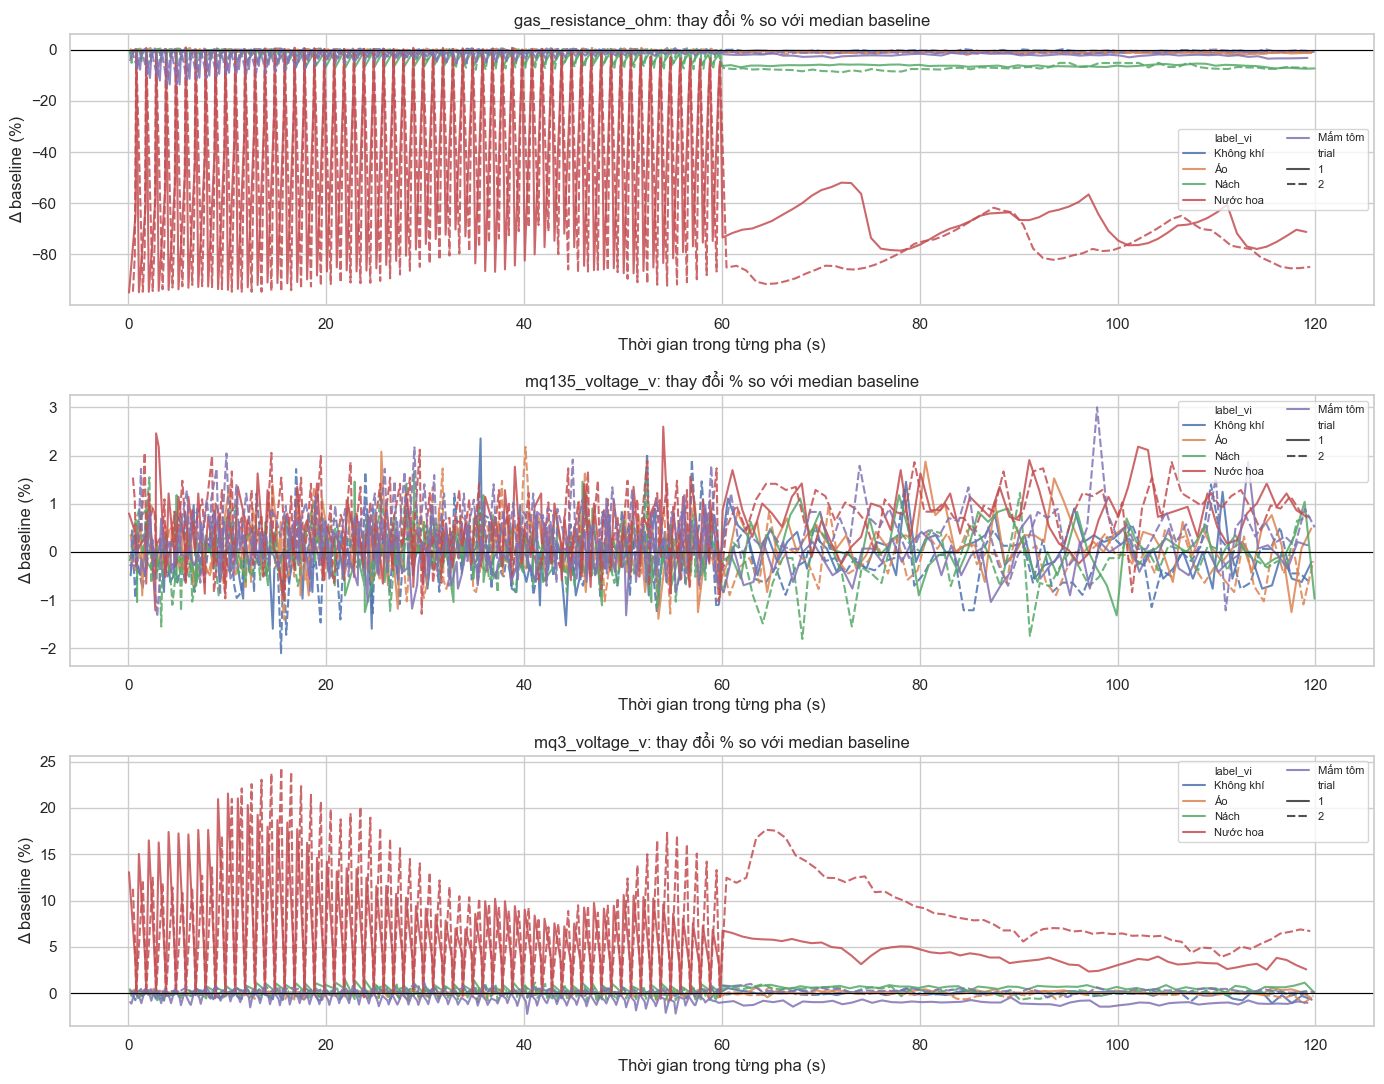

In [5]:
def baseline_normalize(group):
    group = group.copy()
    base = group[group.phase.eq("BASELINE")]
    for s in SIGNALS:
        b = base[s].median()
        group[f"{s}_baseline"] = b
        group[f"{s}_pct"] = 100 * (group[s] / b - 1) if pd.notna(b) and b != 0 else np.nan
    return group

norm = (
    raw_all.groupby("folder", group_keys=False, sort=False)
    .apply(baseline_normalize, include_groups=False)
    .reset_index(drop=True)
)
# groupby/apply ở pandas 3 bỏ cột grouping; khôi phục provenance theo run_id nếu cần.
provenance = raw_all[["run_id", "folder", "trial", "label", "label_vi", "run_order"]].drop_duplicates("run_id")
for c in ["folder", "trial", "label", "label_vi", "run_order"]:
    if c not in norm:
        norm = norm.merge(provenance[["run_id", c]], on="run_id", how="left")

PHASE_COLORS = {"BASELINE": "#4c78a8", "EXPOSURE": "#e45756", "RECOVERY": "#54a24b"}
fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(14, 11), sharex=False)
for ax, s in zip(axes, SIGNALS):
    sns.lineplot(
        data=norm[norm.phase.isin(PHASES)], x="phase_elapsed_s", y=f"{s}_pct",
        hue="label_vi", style="trial", units="folder", estimator=None, alpha=.85, ax=ax,
    )
    ax.axhline(0, color="black", lw=.8)
    ax.set(title=f"{s}: thay đổi % so với median baseline", xlabel="Thời gian trong từng pha (s)", ylabel="Δ baseline (%)")
    ax.legend(ncol=2, fontsize=8)
plt.tight_layout()

Biểu đồ trên chồng ba pha về cùng trục `phase_elapsed_s`; để thấy rõ chuyển pha và carry-over, biểu đồ tiếp theo căn chỉnh exposure rồi nối recovery.

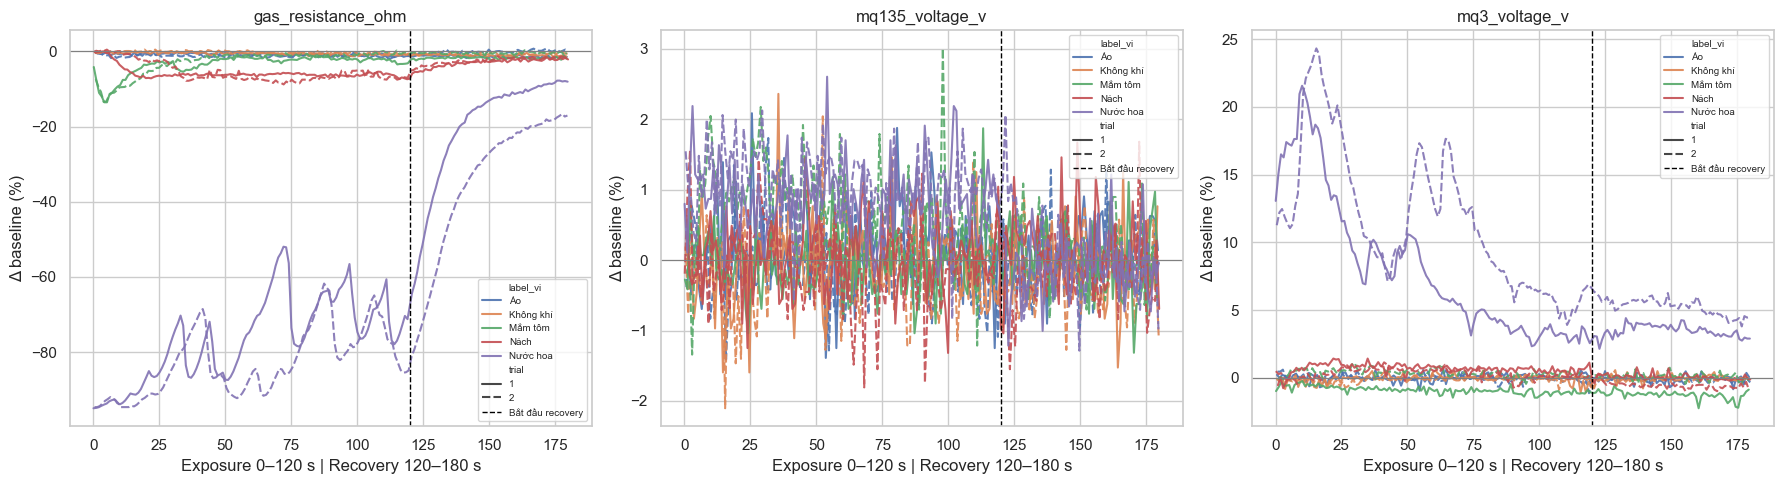

In [6]:
aligned_parts = []
for folder, g in norm.groupby("folder"):
    for phase, offset in [("EXPOSURE", 0), ("RECOVERY", 120)]:
        part = g[g.phase.eq(phase)].copy()
        part["aligned_s"] = offset + part["phase_elapsed_s"]
        aligned_parts.append(part)
aligned = pd.concat(aligned_parts, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
for ax, s in zip(axes, SIGNALS):
    sns.lineplot(
        data=aligned, x="aligned_s", y=f"{s}_pct", hue="label_vi", style="trial",
        units="folder", estimator=None, alpha=.9, ax=ax,
    )
    ax.axvline(120, color="black", ls="--", lw=1, label="Bắt đầu recovery")
    ax.axhline(0, color="grey", lw=.8)
    ax.set(title=s, xlabel="Exposure 0–120 s | Recovery 120–180 s", ylabel="Δ baseline (%)")
    ax.legend(fontsize=7)
plt.tight_layout()

## 4. Trích xuất fingerprint cấp run

In [7]:
def safe_slope(t, y):
    ok = np.isfinite(t) & np.isfinite(y)
    return np.polyfit(np.asarray(t)[ok], np.asarray(y)[ok], 1)[0] if ok.sum() >= 3 else np.nan

feature_rows = []
for (folder, trial, label, label_vi), g in norm.groupby(["folder", "trial", "label", "label_vi"], sort=False):
    row = {"folder": folder, "trial": trial, "label": label, "label_vi": label_vi,
           "started_at": g.run_order.iloc[0]}
    for s in SIGNALS:
        col = f"{s}_pct"
        exp = g[g.phase.eq("EXPOSURE")].dropna(subset=[col]).sort_values("phase_elapsed_s")
        rec = g[g.phase.eq("RECOVERY")].dropna(subset=[col]).sort_values("phase_elapsed_s")
        late = exp[exp.phase_elapsed_s >= max(0, exp.phase_elapsed_s.max() - 20)] if len(exp) else exp
        rec_end = rec[rec.phase_elapsed_s >= max(0, rec.phase_elapsed_s.max() - 10)] if len(rec) else rec
        prefix = {"gas_resistance_ohm": "bme_gas", "mq135_voltage_v": "mq135", "mq3_voltage_v": "mq3"}[s]
        row.update({
            f"{prefix}__mean_pct": exp[col].mean(),
            f"{prefix}__late20_pct": late[col].mean(),
            f"{prefix}__min_pct": exp[col].min(),
            f"{prefix}__max_pct": exp[col].max(),
            f"{prefix}__abs_auc_pct_s": np.trapezoid(np.abs(exp[col]), exp.phase_elapsed_s) if len(exp) >= 2 else np.nan,
            f"{prefix}__slope_pct_min": 60 * safe_slope(exp.phase_elapsed_s, exp[col]),
            f"{prefix}__recovery_end_pct": rec_end[col].mean(),
        })
    base = g[g.phase.eq("BASELINE")]
    row["baseline_temp_c"] = base.temperature_c.mean()
    row["baseline_humidity_pct"] = base.humidity_pct.mean()
    feature_rows.append(row)

features = pd.DataFrame(feature_rows).sort_values(["trial", "started_at"]).reset_index(drop=True)
feature_cols = [c for c in features if "__" in c]
model_features = [c for c in feature_cols if c.endswith(("__mean_pct", "__late20_pct", "__min_pct", "__max_pct", "__slope_pct_min"))]
print(f"Fingerprint: {len(features)} run × {len(feature_cols)} đặc trưng; tập gọn để so khớp: {len(model_features)} đặc trưng")
display(features[["trial", "label_vi", *feature_cols]].round(3))

Fingerprint: 10 run × 21 đặc trưng; tập gọn để so khớp: 15 đặc trưng


,trial,label_vi,bme_gas__mean_pct,bme_gas__late20_pct,bme_gas__min_pct,bme_gas__max_pct,bme_gas__abs_auc_pct_s,bme_gas__slope_pct_min,bme_gas__recovery_end_pct,mq135__mean_pct,mq135__late20_pct,mq135__min_pct,mq135__max_pct,mq135__abs_auc_pct_s,mq135__slope_pct_min,mq135__recovery_end_pct,mq3__mean_pct,mq3__late20_pct,mq3__min_pct,mq3__max_pct,mq3__abs_auc_pct_s,mq3__slope_pct_min,mq3__recovery_end_pct
0,1,Không khí,-0.533,-0.874,-1.311,0.210,64.418,-0.372,-1.064,-0.034,-0.185,-1.595,2.358,47.087,0.053,0.270,-0.052,-0.227,-1.075,0.547,22.591,0.001,-0.079
1,1,Áo,-0.776,-1.307,-1.891,-0.069,92.497,-0.413,-1.385,0.174,0.094,-1.389,2.083,53.124,0.057,0.076,0.036,0.074,-0.943,0.679,19.358,0.040,-0.091
2,1,Nách,-5.786,-6.283,-7.378,0.000,690.488,-1.284,-1.971,0.082,0.040,-1.319,1.457,46.806,0.022,-0.042,0.706,0.544,-0.755,1.434,87.642,-0.085,-0.060
3,1,Nước hoa,-76.582,-71.780,-94.969,-51.972,9106.607,14.148,-8.253,0.867,0.966,-0.243,2.601,104.682,-0.048,-0.104,8.164,3.187,2.341,21.555,971.896,-8.141,3.054
4,1,Mắm tôm,-3.435,-2.447,-13.527,-1.173,408.547,2.945,-1.731,-0.075,0.046,-1.039,1.870,38.850,0.004,-0.222,-0.881,-1.108,-1.451,-0.223,104.764,-0.296,-1.530
5,2,Không khí,-0.212,-0.539,-0.992,0.503,38.219,-0.326,-0.379,-0.155,-0.079,-2.103,2.040,52.427,0.015,-0.191,-0.084,-0.034,-0.865,0.541,21.578,0.112,-0.066
6,2,Mắm tôm,-2.751,-0.465,-13.419,0.250,326.856,4.404,-0.383,0.680,0.387,-1.342,3.003,90.958,-0.316,-0.058,0.370,0.273,-0.470,1.120,47.146,-0.159,0.003
7,2,Áo,-1.124,-1.045,-1.956,-0.311,134.255,-0.011,0.262,-0.079,-0.257,-1.411,1.732,45.380,-0.168,0.006,-0.007,-0.148,-1.120,0.614,23.391,-0.169,-0.194
8,2,Nước hoa,-82.900,-75.762,-94.666,-61.776,9858.228,9.795,-17.784,1.065,0.949,-0.836,2.122,129.936,-0.181,-0.270,11.567,5.623,3.913,24.312,1379.095,-6.481,4.301
9,2,Nách,-5.478,-6.459,-8.771,0.495,656.718,-3.285,-1.631,-0.067,-0.015,-1.808,1.549,50.161,-0.126,-0.207,0.312,0.117,-0.721,1.153,47.694,-0.149,-0.631


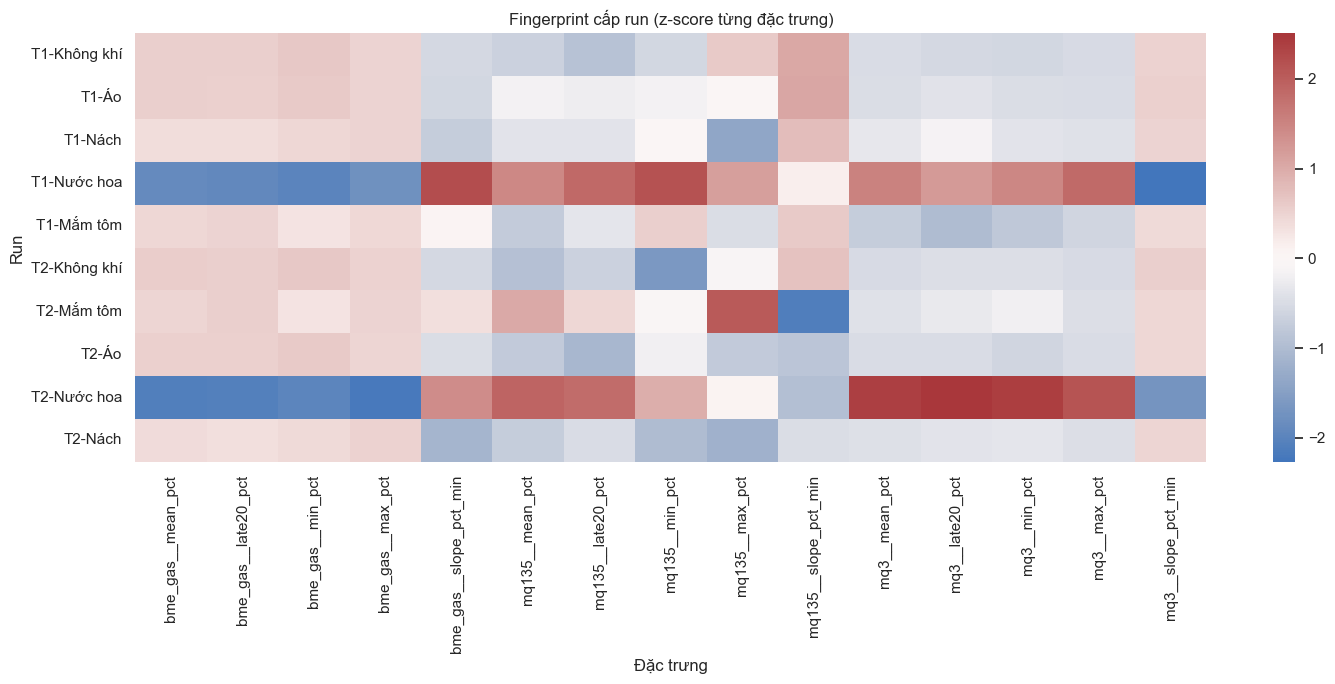

In [8]:
# Heatmap fingerprint đã z-score theo đặc trưng để so hình dạng, không so đơn vị.
X = features[model_features].copy()
X = X.fillna(X.median())
Xz = StandardScaler().fit_transform(X)
row_names = features.apply(lambda r: f"T{r.trial}-{r.label_vi}", axis=1)
plt.figure(figsize=(15, 7))
sns.heatmap(pd.DataFrame(Xz, index=row_names, columns=model_features), cmap="vlag", center=0)
plt.title("Fingerprint cấp run (z-score từng đặc trưng)")
plt.xlabel("Đặc trưng")
plt.ylabel("Run")
plt.tight_layout()

## 5. PCA mô tả và độ lặp lại giữa hai trial

,PC,explained_variance
0,PC1,0.809
1,PC2,0.093


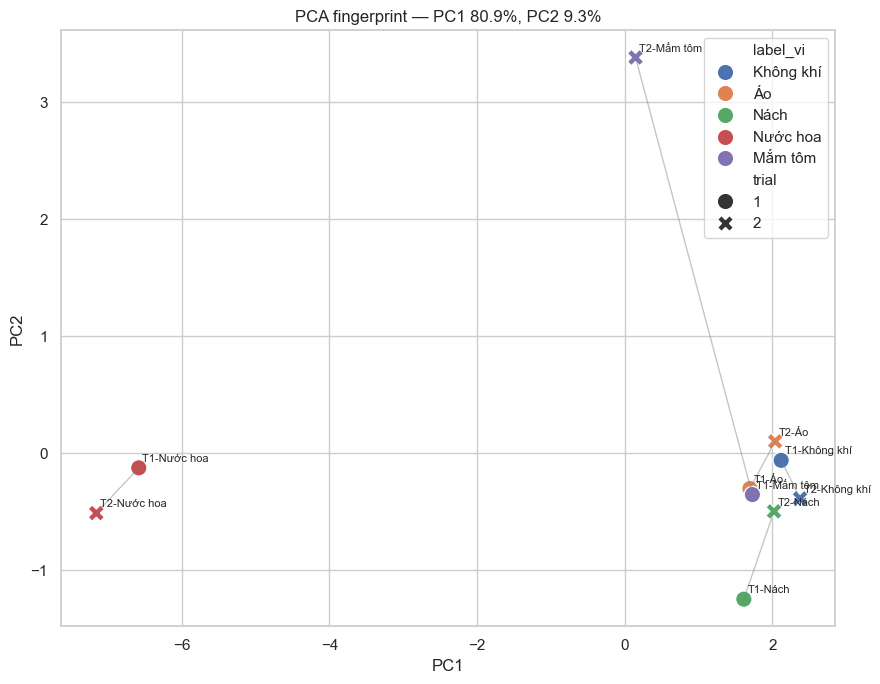

In [9]:
pca = PCA(n_components=2)
Z = pca.fit_transform(Xz)
pca_df = features[["folder", "trial", "label", "label_vi", "started_at"]].copy()
pca_df[["PC1", "PC2"]] = Z

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="label_vi", style="trial", s=140, ax=ax)
for _, r in pca_df.iterrows():
    ax.text(r.PC1 + .05, r.PC2 + .05, f"T{r.trial}-{r.label_vi}", fontsize=8)
for label, g in pca_df.groupby("label"):
    if len(g) == 2:
        ax.plot(g.PC1, g.PC2, color="grey", alpha=.45, lw=1)
ax.set_title(f"PCA fingerprint — PC1 {pca.explained_variance_ratio_[0]:.1%}, PC2 {pca.explained_variance_ratio_[1]:.1%}")
plt.tight_layout()
display(pd.DataFrame({"PC": ["PC1", "PC2"], "explained_variance": pca.explained_variance_ratio_}).round(3))

Median cùng nhãn: 2.314
Median khác nhãn: 4.194
Tỷ lệ separation (khác/cùng): 1.81 (>1 là tín hiệu tích cực)


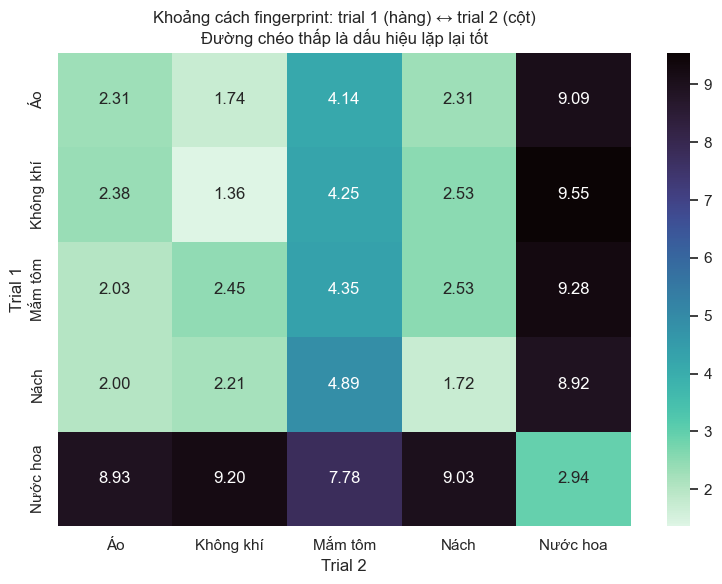

In [10]:
# Khoảng cách chéo trial: mỗi hàng trial 1, mỗi cột trial 2.
t1 = features[features.trial.eq(1)].sort_values("label").reset_index(drop=True)
t2 = features[features.trial.eq(2)].sort_values("label").reset_index(drop=True)

# Scale chung chỉ dùng để mô tả khoảng cách; phép dự đoán ở cell sau fit scaler trên reference trial.
scaler_desc = StandardScaler().fit(features[model_features].fillna(features[model_features].median()))
A = scaler_desc.transform(t1[model_features].fillna(features[model_features].median()))
B = scaler_desc.transform(t2[model_features].fillna(features[model_features].median()))
D = cdist(A, B)
dist_df = pd.DataFrame(D, index=t1.label_vi, columns=t2.label_vi)

plt.figure(figsize=(8, 6))
sns.heatmap(dist_df, annot=True, fmt=".2f", cmap="mako_r")
plt.title("Khoảng cách fingerprint: trial 1 (hàng) ↔ trial 2 (cột)\nĐường chéo thấp là dấu hiệu lặp lại tốt")
plt.xlabel("Trial 2")
plt.ylabel("Trial 1")
plt.tight_layout()

within = np.diag(D)
between = D[~np.eye(len(D), dtype=bool)]
separation_ratio = np.median(between) / np.median(within)
print(f"Median cùng nhãn: {np.median(within):.3f}")
print(f"Median khác nhãn: {np.median(between):.3f}")
print(f"Tỷ lệ separation (khác/cùng): {separation_ratio:.2f} (>1 là tín hiệu tích cực)")

## 6. Baseline phân biệt mùi — ghép nearest-neighbour chéo trial

Đây là kiểm tra “trial còn lại có gần fingerprint đúng nhãn nhất không?”, không phải mô hình đủ mạnh để triển khai. Mỗi phía chỉ có đúng 1 mẫu tham chiếu mỗi lớp. StandardScaler luôn fit trên trial tham chiếu để tránh dùng thông tin test.

,feature_set,reference_trial,query_trial,correct,n,accuracy
0,BME gas,1,2,5,5,1.0
1,BME gas,2,1,3,5,0.6
2,MQ135 + MQ3,1,2,2,5,0.4
3,MQ135 + MQ3,2,1,3,5,0.6
4,Tất cả gas sensors,1,2,4,5,0.8
5,Tất cả gas sensors,2,1,3,5,0.6


,feature_set,reference_trial,query_trial,true,pred,distance,correct
20,Tất cả gas sensors,1,2,Không khí,Không khí,1.738857,True
21,Tất cả gas sensors,1,2,Mắm tôm,Mắm tôm,9.224674,True
22,Tất cả gas sensors,1,2,Áo,Mắm tôm,4.716640,False
23,Tất cả gas sensors,1,2,Nước hoa,Nước hoa,4.661214,True
24,Tất cả gas sensors,1,2,Nách,Nách,4.037527,True
25,Tất cả gas sensors,2,1,Không khí,Không khí,1.434699,True
26,Tất cả gas sensors,2,1,Áo,Không khí,1.873941,False
27,Tất cả gas sensors,2,1,Nách,Nách,1.894808,True
28,Tất cả gas sensors,2,1,Nước hoa,Nước hoa,2.930765,True
29,Tất cả gas sensors,2,1,Mắm tôm,Áo,2.172402,False


Độ đúng theo từng nhãn (chỉ 2 truy vấn/nhãn):


,correct,n,accuracy
true,,,
Không khí,2,2,1.0
Mắm tôm,1,2,0.5
Nách,2,2,1.0
Nước hoa,2,2,1.0
Áo,0,2,0.0


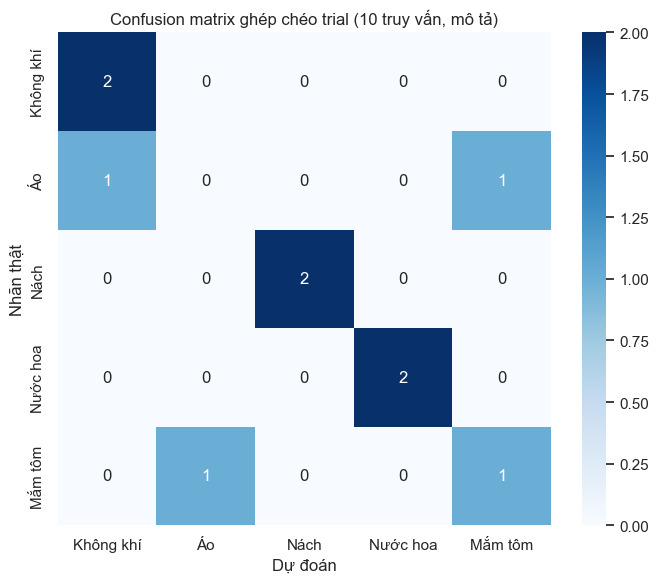

In [11]:
FEATURE_SETS = {
    "BME gas": [c for c in model_features if c.startswith("bme_gas__")],
    "MQ135 + MQ3": [c for c in model_features if c.startswith(("mq135__", "mq3__"))],
    "Tất cả gas sensors": model_features,
}

pred_rows = []
for feature_set, cols in FEATURE_SETS.items():
    for ref_trial, query_trial in [(1, 2), (2, 1)]:
        ref = features[features.trial.eq(ref_trial)].reset_index(drop=True)
        query = features[features.trial.eq(query_trial)].reset_index(drop=True)
        med = ref[cols].median()
        scaler = StandardScaler().fit(ref[cols].fillna(med))
        R = scaler.transform(ref[cols].fillna(med))
        Q = scaler.transform(query[cols].fillna(med))
        distances = cdist(Q, R)
        nearest = distances.argmin(axis=1)
        for i, j in enumerate(nearest):
            pred_rows.append({
                "feature_set": feature_set,
                "reference_trial": ref_trial,
                "query_trial": query_trial,
                "true": query.loc[i, "label_vi"],
                "pred": ref.loc[j, "label_vi"],
                "distance": distances[i, j],
                "correct": query.loc[i, "label"] == ref.loc[j, "label"],
            })

predictions = pd.DataFrame(pred_rows)
scores = predictions.groupby(["feature_set", "reference_trial", "query_trial"]).agg(
    correct=("correct", "sum"), n=("correct", "size"), accuracy=("correct", "mean")
).reset_index()
display(scores)
display(predictions[predictions.feature_set.eq("Tất cả gas sensors")])

all_pred = predictions[predictions.feature_set.eq("Tất cả gas sensors")]
print("Độ đúng theo từng nhãn (chỉ 2 truy vấn/nhãn):")
display(all_pred.groupby("true").agg(correct=("correct", "sum"), n=("correct", "size"), accuracy=("correct", "mean")))
labels_order = list(LABEL_VI.values())
cm = confusion_matrix(all_pred.true, all_pred.pred, labels=labels_order)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order)
plt.title("Confusion matrix ghép chéo trial (10 truy vấn, mô tả)")
plt.xlabel("Dự đoán")
plt.ylabel("Nhãn thật")
plt.tight_layout()

**Không dùng accuracy này làm bằng chứng cuối:** có 5 lớp × 2 run, không có tập test độc lập theo ngày/người, và thứ tự đo/carry-over vẫn là biến gây nhiễu. Accuracy ngẫu nhiên danh nghĩa là 20%, nhưng khoảng tin cậy với chỉ 10 truy vấn rất rộng.

## 7. Kiểm tra drift môi trường và thứ tự thu

,feature,nuisance,spearman_rho,p_value,abs_rho
29,mq135__slope_pct_min,collection_index,-0.830,0.003,0.830
28,mq135__slope_pct_min,baseline_humidity_pct,-0.770,0.009,0.770
39,mq3__max_pct,baseline_temp_c,-0.588,0.074,0.588
43,mq3__slope_pct_min,baseline_humidity_pct,-0.576,0.082,0.576
30,mq3__mean_pct,baseline_temp_c,-0.539,0.108,0.539
33,mq3__late20_pct,baseline_temp_c,-0.527,0.117,0.527
27,mq135__slope_pct_min,baseline_temp_c,0.455,0.187,0.455
0,bme_gas__mean_pct,baseline_temp_c,0.442,0.200,0.442
13,bme_gas__slope_pct_min,baseline_humidity_pct,0.430,0.214,0.430
3,bme_gas__late20_pct,baseline_temp_c,0.430,0.214,0.430


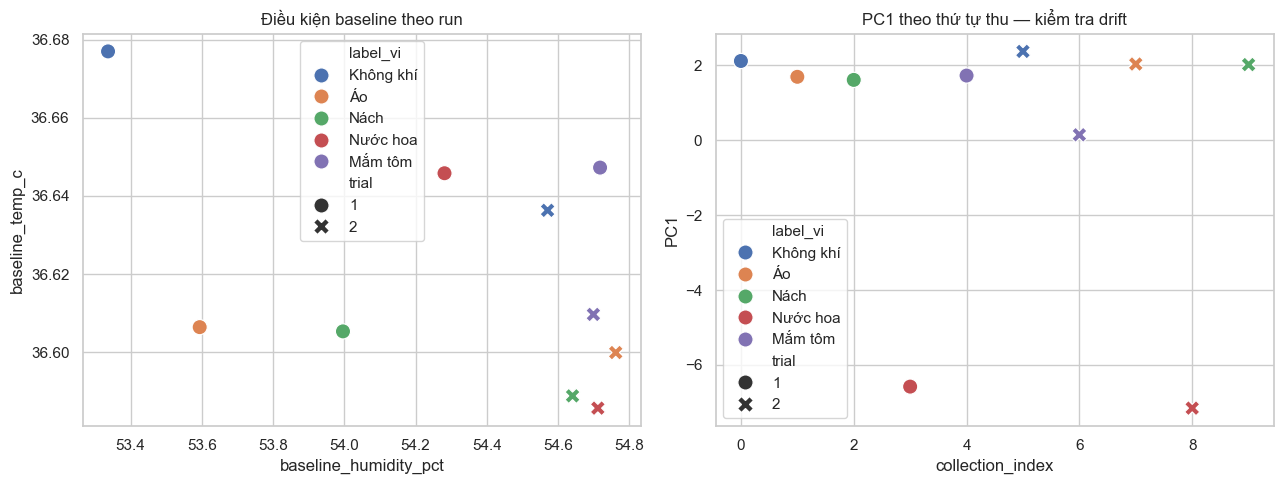

In [12]:
features_ordered = features.sort_values("started_at").copy()
features_ordered["collection_index"] = np.arange(len(features_ordered))

confound_rows = []
for c in model_features:
    for nuisance in ["baseline_temp_c", "baseline_humidity_pct", "collection_index"]:
        rho, p = spearmanr(features_ordered[c], features_ordered[nuisance], nan_policy="omit")
        confound_rows.append({"feature": c, "nuisance": nuisance, "spearman_rho": rho, "p_value": p})
confounds = pd.DataFrame(confound_rows)
display(confounds.assign(abs_rho=confounds.spearman_rho.abs()).sort_values("abs_rho", ascending=False).head(15).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=features_ordered, x="baseline_humidity_pct", y="baseline_temp_c", hue="label_vi", style="trial", s=120, ax=axes[0])
axes[0].set_title("Điều kiện baseline theo run")
plot_order = pca_df.merge(features_ordered[["folder", "collection_index"]], on="folder", how="left")
sns.scatterplot(data=plot_order,
                x="collection_index", y="PC1", hue="label_vi", style="trial", s=120, ax=axes[1])
axes[1].set_title("PC1 theo thứ tự thu — kiểm tra drift")
plt.tight_layout()

## 8. Kết luận tự động từ dữ liệu hiện tại

In [13]:
all_score = scores[scores.feature_set.eq("Tất cả gas sensors")].accuracy.mean()
worst_recovery = quality.filter(regex="recovery_end_pct$").abs().max().max()
invalid_min = quality.filter(regex="valid_pct$").min().min()

if separation_ratio > 1.5 and all_score >= 0.6:
    device_signal = "Có tín hiệu phân tách sơ bộ đáng để thu dataset lớn hơn; nước hoa tách rất mạnh, còn áo/không khí/mắm tôm có nhầm lẫn"
elif separation_ratio > 1.0 or all_score > 0.2:
    device_signal = "Có tín hiệu yếu/trung bình, nhưng độ lặp lại chưa đủ thuyết phục"
else:
    device_signal = "Chưa thấy fingerprint lặp lại đủ rõ giữa hai trial"

display(Markdown(f'''
### Nhận định

- **Odor A so với odor B:** {device_signal}. Tỷ lệ khoảng cách khác/cùng nhãn = **{separation_ratio:.2f}**; accuracy ghép chéo trial trung bình = **{all_score:.0%}**.
- **Độ lớn đáp ứng:** nước hoa làm BME gas giảm khoảng **77–83%** và MQ3 tăng trung bình **8–12%**; nách làm BME gas giảm khoảng **5.5–5.8%**. Áo và không khí chỉ làm BME gas đổi khoảng **0.2–1.1%**, nên đây là cặp khó hơn.
- **Chất lượng thu:** valid-rate thấp nhất = **{invalid_min:.1f}%**; độ lệch recovery lớn nhất theo trị tuyệt đối = **{worst_recovery:.1f}%**. Recovery xa 0 làm carry-over đáng lo.
- **Nhận diện người:** **chưa thể đánh giá** vì không có nhiều người, `person_code` trống và chỉ có 2 run/lớp. Áo/nách hiện là loại nguồn mẫu, không phải nhãn người.
- **Ý nghĩa thống kê:** n=2/lớp không đủ ước lượng phương sai nội lớp, khoảng tin cậy hay khả năng tổng quát hoá. PCA/accuracy ở đây chỉ là công cụ chẩn đoán.
'''))


### Nhận định

- **Odor A so với odor B:** Có tín hiệu phân tách sơ bộ đáng để thu dataset lớn hơn; nước hoa tách rất mạnh, còn áo/không khí/mắm tôm có nhầm lẫn. Tỷ lệ khoảng cách khác/cùng nhãn = **1.81**; accuracy ghép chéo trial trung bình = **70%**.
- **Độ lớn đáp ứng:** nước hoa làm BME gas giảm khoảng **77–83%** và MQ3 tăng trung bình **8–12%**; nách làm BME gas giảm khoảng **5.5–5.8%**. Áo và không khí chỉ làm BME gas đổi khoảng **0.2–1.1%**, nên đây là cặp khó hơn.
- **Chất lượng thu:** valid-rate thấp nhất = **99.9%**; độ lệch recovery lớn nhất theo trị tuyệt đối = **16.5%**. Recovery xa 0 làm carry-over đáng lo.
- **Nhận diện người:** **chưa thể đánh giá** vì không có nhiều người, `person_code` trống và chỉ có 2 run/lớp. Áo/nách hiện là loại nguồn mẫu, không phải nhãn người.
- **Ý nghĩa thống kê:** n=2/lớp không đủ ước lượng phương sai nội lớp, khoảng tin cậy hay khả năng tổng quát hoá. PCA/accuracy ở đây chỉ là công cụ chẩn đoán.


## 9. Thiết kế vòng thu tiếp theo

### Để kiểm tra phân biệt mùi A/B

1. Ít nhất 10–20 lần đo độc lập mỗi loại, trải trên ≥3 ngày; random hoá thứ tự mẫu trong từng block.
2. Có blank không khí trước/sau mẫu mạnh; purge theo điều kiện “tín hiệu về trong ±2–5% baseline”, không chỉ cố định 60 s.
3. Chuẩn hoá khoảng cách cup, thời gian lấy mẫu, lưu lượng bơm, lượng/nồng độ mẫu và thời gian từ chuẩn bị đến đo.
4. Mắm tôm/nước hoa nên có tubing/cup riêng hoặc blank xác nhận hết carry-over.
5. BME688 hiện chạy 320 °C cố định. Nếu phần mềm/phần cứng cho phép, dùng heater profile nhiều nhiệt độ để fingerprint giàu hơn.

### Để kiểm tra nhận diện người

1. Tối thiểu 10 người cho pilot, tốt hơn 20–30; mỗi người ≥5 lần/ngày × ≥3 ngày, cùng vị trí cơ thể và protocol.
2. Ghi `person_code`, session/day, vị trí, thời gian, chế độ ăn, mỹ phẩm/nước hoa, vận động, nhiệt độ/độ ẩm phòng.
3. Cần hai bài toán tách biệt:
   - **Closed-set identification:** người trong test đã xuất hiện ở train, nhưng test là ngày/session khác.
   - **Verification:** cùng người hay khác người; báo ROC-AUC, EER và khoảng tin cậy.
4. Split theo **session/day**, không split theo dòng và không để các cửa sổ của cùng run nằm cả train lẫn test.
5. So sánh với baseline đơn giản (nearest centroid/logistic regression), rồi mới thử Random Forest/SVM; deep learning chưa phù hợp khi số run còn nhỏ.

### Tiêu chí go/no-go đề xuất

- Go: baseline ổn định, ≥90% run recovery về ±5%, fingerprint cùng mẫu gần nhau hơn khác mẫu một cách nhất quán, và balanced accuracy group-CV vượt baseline với CI rõ.
- No-go/tối ưu phần cứng: tín hiệu chủ yếu bám theo thời gian/nhiệt độ/độ ẩm, carry-over lớn, hoặc độ lệch giữa ngày lớn hơn độ lệch giữa nhãn.

## 10. Ghi chú tái lập

Notebook đọc trực tiếp `data/first_trial/*/{metadata,summary}.json` và `raw.csv`; không sử dụng ảnh PNG làm nguồn số liệu. Ảnh trong từng run là sản phẩm trực quan hoá từ chính dữ liệu này. Khi thêm run mới đúng quy ước `trialNN_<label>_...`, cần mở rộng regex/logic trial nếu `NN > 02`.